# RavenStack SaaS — Cohort Retention

**Author:** Namık Akman  
**Question:** Do customers churn *early* (onboarding problem) or *late* (value-erosion problem)?

The answer changes what we'd do about it: an early-churn business should invest in onboarding and time-to-value; a late-churn business should invest in product depth, customer success at renewal, and expansion features.

## Method

- Each customer's **exit date** = their latest churn event (excluding reactivations). If they're still active, exit date = observation end (2024-12-31).
- **Tenure (months)** = exit date − signup date.
- **Cohort** = signup month (or quarter for the line chart).
- **Survival at month N** = share of cohort members with tenure ≥ N.
- To avoid censoring bias, each cohort is only shown up to the month all its members could be observed.

## 1. Setup and build the cohort table

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

DATA = Path(r'C:\Users\Lenovo\OneDrive\Creative\Churn Study\data')

BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE = '#2F9BFF', '#19C37D', '#FF6500'
BG_DARK, FG_LIGHT = '#0F1419', '#E6EDF3'
plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_DARK, 'savefig.facecolor': BG_DARK,
    'axes.edgecolor': FG_LIGHT, 'axes.labelcolor': FG_LIGHT,
    'xtick.color': FG_LIGHT, 'ytick.color': FG_LIGHT, 'text.color': FG_LIGHT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

accounts = pd.read_csv(DATA / 'ravenstack_accounts.csv', parse_dates=['signup_date'])
churn_events = pd.read_csv(DATA / 'ravenstack_churn_events.csv', parse_dates=['churn_date'])
obs_end = max(accounts['signup_date'].max(), churn_events['churn_date'].max())
print('Observation cutoff:', obs_end.date())

# True exits only (skip reactivations)
real_churns = churn_events[~churn_events['is_reactivation'].astype(bool)]
last_churn = real_churns.groupby('account_id')['churn_date'].max().rename('last_churn_date')

df = accounts.merge(last_churn, on='account_id', how='left')
df['exit_date'] = pd.to_datetime(np.where(df['churn_flag'], df['last_churn_date'].fillna(obs_end), obs_end))
df['tenure_months'] = ((df['exit_date'] - df['signup_date']).dt.days // 30).astype(int)
df['observable_months'] = ((obs_end - df['signup_date']).dt.days // 30).astype(int)
df['cohort'] = df['signup_date'].dt.to_period('M').astype(str)
df['cohort_q'] = df['signup_date'].dt.to_period('Q').astype(str)

print(f'Total: {len(df)} | churned: {df["churn_flag"].sum()}')
print(f'Tenure (months) — min/median/max: {df["tenure_months"].min()} / {df["tenure_months"].median():.0f} / {df["tenure_months"].max()}')

Observation cutoff: 2024-12-31
Total: 500 | churned: 110
Tenure (months) — min/median/max: 0 / 9 / 24


## 2. Pooled retention curve — all customers together

For each month N since signup, take all customers who *could have* been observed to month N, and compute the share still active.  
This gives the cleanest single-line answer to the question.

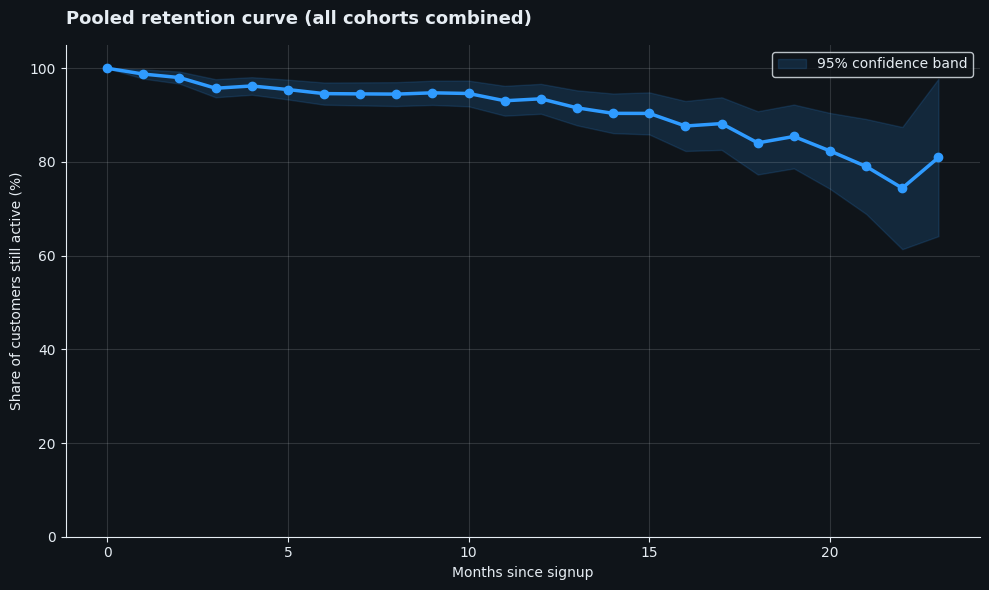

In [2]:
max_m = int(df['observable_months'].max())
pooled = []
for m in range(max_m + 1):
    eligible = df[df['observable_months'] >= m]
    if len(eligible) < 10:
        break
    alive = (eligible['tenure_months'] >= m).mean()
    se = np.sqrt(alive * (1 - alive) / len(eligible))
    pooled.append({'m': m, 'survival': alive, 'n': len(eligible), 'se': se})
pooled = pd.DataFrame(pooled)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pooled['m'], pooled['survival'] * 100, color=BRAND_BLUE, linewidth=2.5, marker='o')
ax.fill_between(pooled['m'],
                (pooled['survival'] - 1.96 * pooled['se']) * 100,
                (pooled['survival'] + 1.96 * pooled['se']) * 100,
                color=BRAND_BLUE, alpha=0.15, label='95% confidence band')
ax.set_xlabel('Months since signup'); ax.set_ylabel('Share of customers still active (%)')
ax.set_title('Pooled retention curve (all cohorts combined)', loc='left', pad=15)
ax.set_ylim(0, 105); ax.grid(True, alpha=0.15, color=FG_LIGHT)
ax.legend(facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT)
plt.tight_layout(); plt.show()

In [3]:
# Key milestones
for m in [3, 6, 12, 18]:
    if m in pooled['m'].values:
        s = pooled.loc[pooled['m'] == m, 'survival'].iloc[0]
        print(f'Retention at month {m:>2}: {s:.1%}')

Retention at month  3: 95.7%
Retention at month  6: 94.6%
Retention at month 12: 93.5%
Retention at month 18: 84.1%


**Read — first pass at the answer:**

- **Month 3:** ~95.7% still active.
- **Month 12:** ~93.5% still active.
- **Month 18:** ~84% still active.

Looking at the *base of 500 customers*, the curve declines gently — only ~5% of the base is gone by month 6. But this view *understates* the early-churn problem because it pools survivors (the majority) with leavers. Section 5 below re-frames the question from the perspective of *churners only*, which gives a different and sharper answer.

## 3. By cohort — are recent cohorts behaving differently?

A pooled curve hides whether retention is *improving or deteriorating* over time. Splitting by signup quarter answers that.

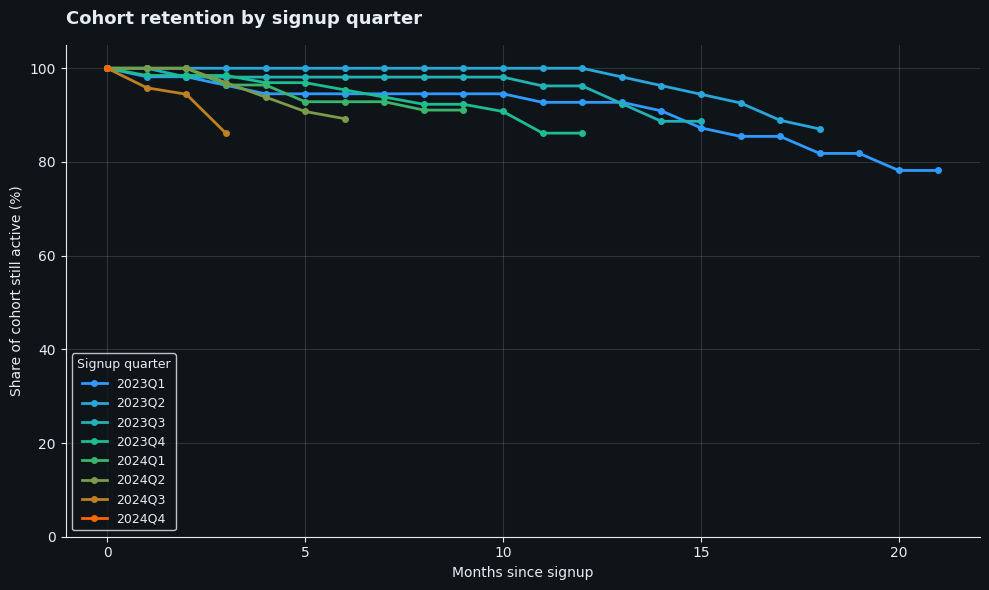

In [4]:
quarters = sorted(df['cohort_q'].unique())
survival_q = pd.DataFrame(index=quarters, columns=range(max_m + 1), dtype=float)
for q in quarters:
    sub = df[df['cohort_q'] == q]
    q_obs = int(sub['observable_months'].min())  # min, so every cell is fair
    for m in range(q_obs + 1):
        survival_q.loc[q, m] = (sub['tenure_months'] >= m).sum() / len(sub)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = LinearSegmentedColormap.from_list('brand', [BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE])
for i, q in enumerate(quarters):
    color = cmap(i / max(1, len(quarters) - 1))
    s = survival_q.loc[q].dropna()
    ax.plot(s.index, s.values * 100, marker='o', markersize=4, linewidth=2, color=color, label=q)
ax.set_xlabel('Months since signup'); ax.set_ylabel('Share of cohort still active (%)')
ax.set_title('Cohort retention by signup quarter', loc='left', pad=15)
ax.set_ylim(0, 105); ax.grid(True, alpha=0.15, color=FG_LIGHT)
ax.legend(title='Signup quarter', facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT,
          title_fontsize=9, fontsize=9)
plt.tight_layout(); plt.show()

**Read:** Cohorts behave *consistently* — they all glide gently downward, then accelerate later. No newer cohort is dramatically worse or better than older ones, which means the retention profile is structural, not the result of a recent product change.

## 4. Heatmap — the full picture, monthly cohorts × months since signup

The classic SaaS retention triangle. Each row is a signup month; each column is N months after signup; each cell is the % still active. The empty (black) area is where the cohort hasn't lived that long yet.

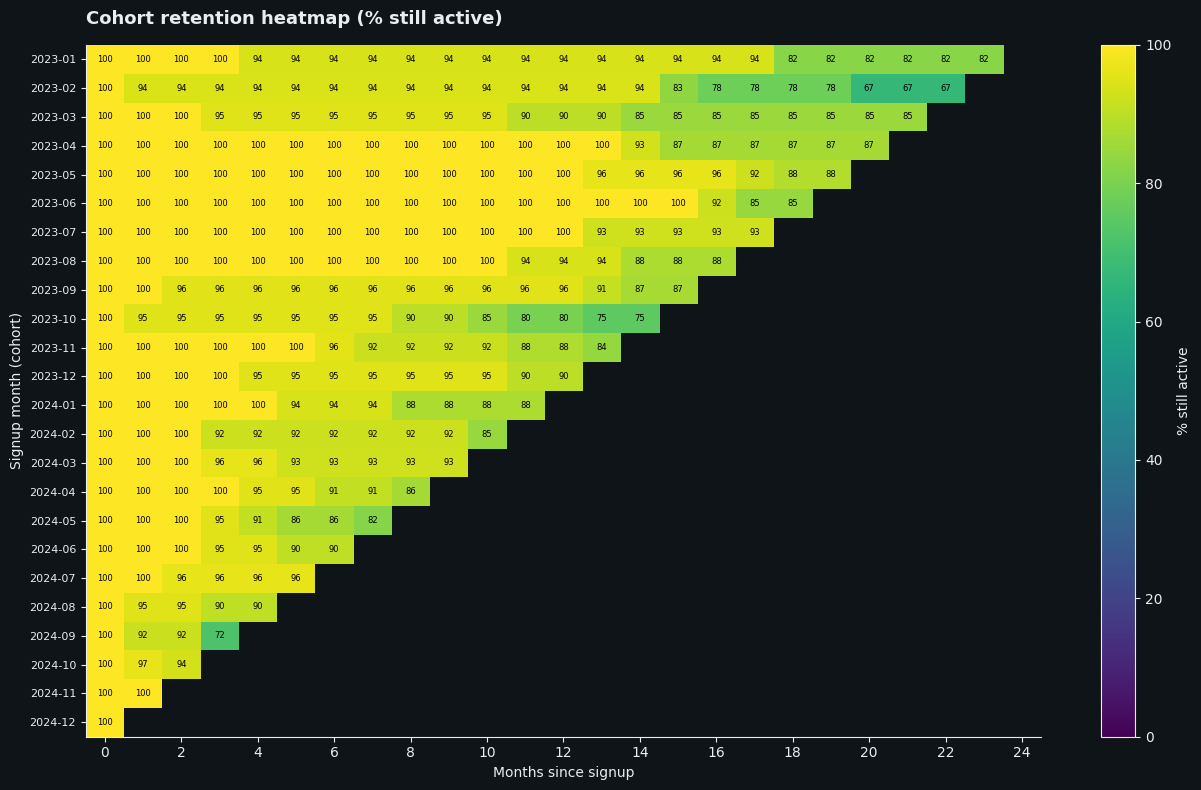

In [5]:
cohorts = sorted(df['cohort'].unique())
survival = pd.DataFrame(index=cohorts, columns=range(max_m + 1), dtype=float)
for c in cohorts:
    sub = df[df['cohort'] == c]
    cohort_obs = int(sub['observable_months'].min())
    for m in range(cohort_obs + 1):
        survival.loc[c, m] = (sub['tenure_months'] >= m).sum() / len(sub)

fig, ax = plt.subplots(figsize=(13, 8))
heatmap = (survival * 100).astype(float)
im = ax.imshow(heatmap.values, aspect='auto', cmap='viridis', vmin=0, vmax=100)
ax.set_yticks(range(len(cohorts))); ax.set_yticklabels(cohorts, fontsize=8)
ax.set_xticks(range(0, max_m + 1, 2)); ax.set_xticklabels(range(0, max_m + 1, 2))
ax.set_xlabel('Months since signup'); ax.set_ylabel('Signup month (cohort)')
ax.set_title('Cohort retention heatmap (% still active)', loc='left', pad=15)
for i in range(len(cohorts)):
    for m in range(max_m + 1):
        v = heatmap.iat[i, m]
        if pd.notna(v):
            ax.text(m, i, f'{v:.0f}', ha='center', va='center', fontsize=6,
                    color=FG_LIGHT if v < 60 else '#000000')
cbar = plt.colorbar(im, ax=ax, label='% still active')
cbar.ax.yaxis.label.set_color(FG_LIGHT); cbar.ax.tick_params(colors=FG_LIGHT)
plt.tight_layout(); plt.show()

**Read the diagonal:** going from top-left (oldest cohort, longest observation) toward bottom-right (newest cohort), every cohort shows the same pattern — high retention through ~month 12, then green/teal cells starting to appear around months 14-21.

The diagonal edge is observation, not churn. The *colors* are the actual story: cohorts stay yellow (>90%) for the first year and only begin to fade in year two.

## 5. At which stage do customers actually leave?

The pooled curve in section 2 looks at the *base of all customers* — and from that angle, churn looks like a late-year-two phenomenon.  
But that view *averages* the survivors (the majority) with the leavers (the minority). To find *where the leaks are*, we need to re-frame the question:

> **Of the customers who actually left, at what tenure did they leave?**

This is the operational view a customer-success team needs.

In [6]:
# Latest stated reason for each churned account
last_reason = (real_churns.sort_values('churn_date')
               .groupby('account_id').tail(1)[['account_id', 'reason_code']]
               .rename(columns={'reason_code': 'last_reason'}))

churned = (accounts[accounts['churn_flag']]
           .merge(last_churn.reset_index(), on='account_id', how='left')
           .merge(last_reason, on='account_id', how='left'))

no_event = churned['last_churn_date'].isna().sum()
churned = churned.dropna(subset=['last_churn_date']).copy()
churned['tenure_months_at_churn'] = ((churned['last_churn_date'] - churned['signup_date']).dt.days // 30).astype(int)

print(f'Churned accounts total       : {accounts["churn_flag"].sum()}')
print(f'  with a real churn event    : {len(churned)}')
print(f'  without (dropped, see note): {no_event}')
print(f'Tenure at churn (months)     : min {churned["tenure_months_at_churn"].min()}, median {churned["tenure_months_at_churn"].median():.0f}, max {churned["tenure_months_at_churn"].max()}')

Churned accounts total       : 110
  with a real churn event    : 74
  without (dropped, see note): 36
Tenure at churn (months)     : min 0, median 6, max 19


**Data-quality note for the write-up:** 110 accounts are flagged churned but only 74 have a recorded churn_event with a date. The other 36 are excluded from this stage analysis — they're real churners we just can't time-stamp. Worth mentioning in the published study as a transparent limitation.

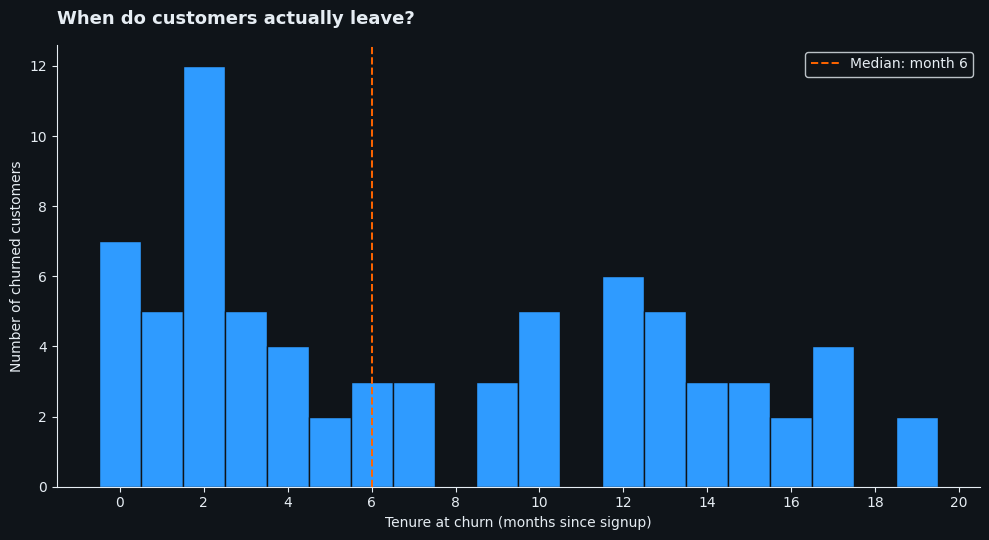

In [7]:
# Histogram of tenure at churn
fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.arange(0, churned['tenure_months_at_churn'].max() + 2) - 0.5
ax.hist(churned['tenure_months_at_churn'], bins=bins, color=BRAND_BLUE, edgecolor=BG_DARK)
median_t = churned['tenure_months_at_churn'].median()
ax.axvline(median_t, color=BRAND_ORANGE, linestyle='--', linewidth=1.4, label=f'Median: month {median_t:.0f}')
ax.set_xlabel('Tenure at churn (months since signup)')
ax.set_ylabel('Number of churned customers')
ax.set_title('When do customers actually leave?', loc='left', pad=15)
ax.set_xticks(range(0, int(churned['tenure_months_at_churn'].max()) + 2, 2))
ax.legend(facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT)
plt.tight_layout(); plt.show()

**Read:** The distribution is clearly **bimodal**. There's a tall cluster of churn in the first 3 months, a quiet middle, and a second peak around months 12–15. That's not a single cliff — it's two different churn populations.

To make this clearer, let's group tenure into business-meaningful lifecycle stages.

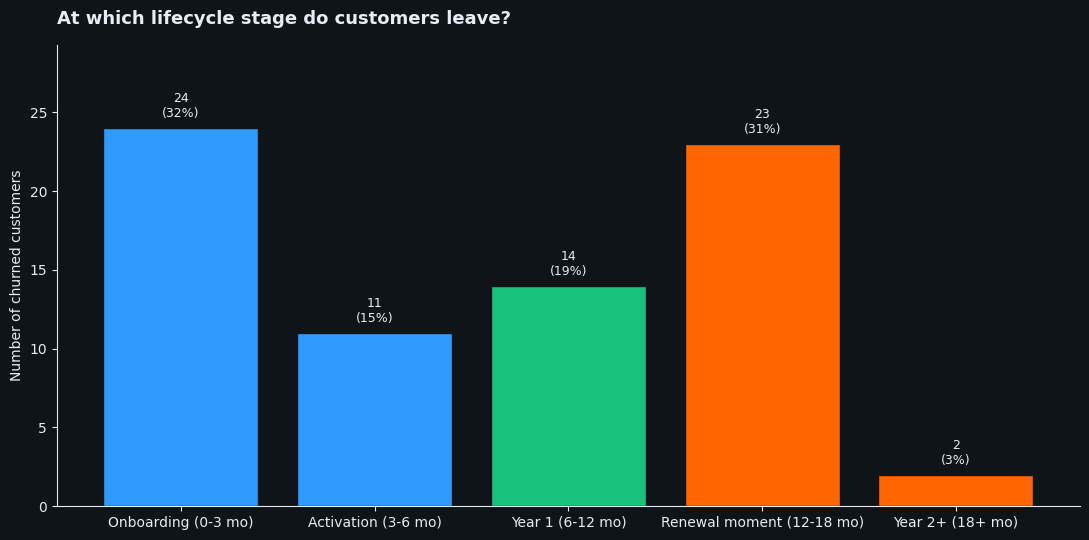


  Onboarding (0-3 mo)              24   (32.4%)
  Activation (3-6 mo)              11   (14.9%)
  Year 1 (6-12 mo)                 14   (18.9%)
  Renewal moment (12-18 mo)        23   (31.1%)
  Year 2+ (18+ mo)                  2   ( 2.7%)


In [8]:
def stage(m):
    if m < 3:   return 'Onboarding (0-3 mo)'
    if m < 6:   return 'Activation (3-6 mo)'
    if m < 12:  return 'Year 1 (6-12 mo)'
    if m < 18:  return 'Renewal moment (12-18 mo)'
    return 'Year 2+ (18+ mo)'

churned['stage'] = churned['tenure_months_at_churn'].apply(stage)
stage_order = ['Onboarding (0-3 mo)', 'Activation (3-6 mo)', 'Year 1 (6-12 mo)',
               'Renewal moment (12-18 mo)', 'Year 2+ (18+ mo)']
stage_counts = churned['stage'].value_counts().reindex(stage_order).fillna(0).astype(int)
stage_pct = (stage_counts / stage_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = [BRAND_BLUE, BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE, BRAND_ORANGE]
bars = ax.bar(stage_counts.index, stage_counts.values, color=colors, edgecolor=BG_DARK)
for bar, c, p in zip(bars, stage_counts.values, stage_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + 0.5, f'{c}\n({p:.0f}%)',
            ha='center', va='bottom', color=FG_LIGHT, fontsize=9)
ax.set_ylabel('Number of churned customers')
ax.set_title('At which lifecycle stage do customers leave?', loc='left', pad=15)
ax.set_ylim(0, max(stage_counts.values) * 1.22)
plt.tight_layout(); plt.show()

print()
for s in stage_order:
    print(f'  {s:<30}  {stage_counts[s]:>3}   ({stage_pct[s]:>4.1f}%)')

**Read — and this is the headline of the whole section:**

| Stage | Share of churners |
| --- | ---:|
| **Onboarding (0–3 mo)** | **32%** |
| Activation (3–6 mo) | 15% |
| Year 1 (6–12 mo) | 19% |
| **Renewal moment (12–18 mo)** | **31%** |
| Year 2+ (18+ mo) | 3% |

Two equal-sized churn populations, separated by ~9 quiet months. These are **two different problems requiring two different fixes**.

- The **onboarding hump** says: the product didn't stick. Either the prospect was poorly qualified, or time-to-value is too long.
- The **renewal hump** says: the product stuck initially, but year-one value didn't translate into year-two confidence.

Activation and year-one are relatively quiet — once a customer makes it past month 3, they tend to stay through to the renewal decision.

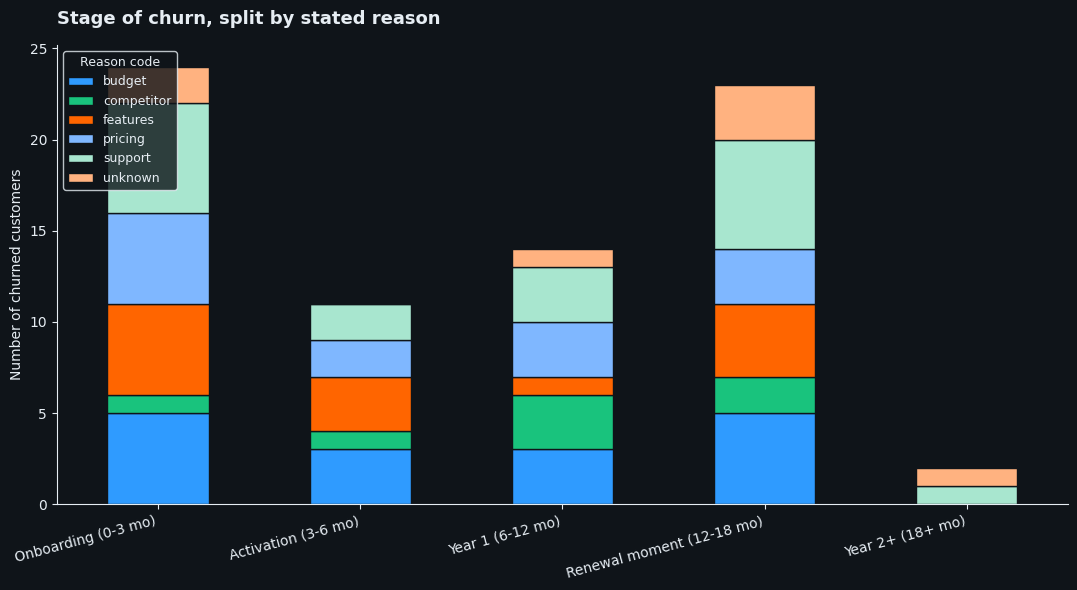

last_reason,budget,competitor,features,pricing,support,unknown
stage,,,,,,
Onboarding (0-3 mo),5,1,5,5,6,2
Activation (3-6 mo),3,1,3,2,2,0
Year 1 (6-12 mo),3,3,1,3,3,1
Renewal moment (12-18 mo),5,2,4,3,6,3
Year 2+ (18+ mo),0,0,0,0,1,1


In [9]:
# Stage × stated reason
stage_reason = pd.crosstab(churned['stage'], churned['last_reason'])
stage_reason = stage_reason.reindex(stage_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
reason_colors = [BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE, '#7FB7FF', '#A8E6CF', '#FFB280']
stage_reason.plot(kind='bar', stacked=True, color=reason_colors[:stage_reason.shape[1]],
                  ax=ax, edgecolor=BG_DARK)
ax.set_ylabel('Number of churned customers'); ax.set_xlabel('')
ax.set_title('Stage of churn, split by stated reason', loc='left', pad=15)
ax.legend(title='Reason code', facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT,
          title_fontsize=9, fontsize=9, loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()
stage_reason

**Read the reason mix:**

- **Onboarding churners** cite *features* and *pricing* heavily — they decided the product wasn't the right fit, or wasn't worth the cost. The implicit message: *"This isn't for us."*
- **Renewal-moment churners** are dominated by *support* complaints, then features and budget. After a year, dissatisfaction with how they're being supported is the single biggest reason given.

Two churn populations → two distinct interventions:
- **For onboarding churn:** sharper pre-purchase qualification, pricing transparency on the website, faster time-to-first-value, possibly a 30-day money-back guarantee to remove pre-purchase risk.
- **For renewal churn:** invest in support quality, especially during months 9–12 when the renewal trigger is approaching. Proactive customer-success outreach before the contract anniversary.

---
## What this section adds to the study

We came in asking *when* customers churn. The pooled curve gave one answer ("mostly late"). The stage view gave a sharper, truer answer:

> **RavenStack doesn't have one churn problem — it has two, of roughly equal size.** ~32% of churners leave in the first 3 months (an *onboarding* failure), and ~31% leave at the 12–18 month renewal moment (a *value-erosion / support* failure). The middle months are quiet.

Combined with notebook 1's segmentation findings:
- Churn is concentrated in the **DevTools** industry (~31% lifetime).
- Churn is concentrated in customers acquired through **events** (~30% lifetime vs ~15% for partner-sourced).
- Plan tier does not predict churn.

The emerging executive headline:

> *RavenStack has two distinct churn populations of equal size — an onboarding leak in months 0–3 and a renewal leak in months 12–18 — and both are concentrated in DevTools customers acquired through events. Fixing either requires a different playbook: pre-purchase qualification for the early hump, customer-success investment for the late hump.*

## Where to go next

- **Feature usage vs retention** — does engagement fall *before* customers churn? Is there a 'magic moment' feature retained customers use?
- **Support tickets vs churn** — do tickets in months 9–12 predict churn at month 13–18? (The renewal-hump hypothesis suggests yes.)
- **Survival model** — quantify how much each factor (industry, channel, tickets, usage) shifts the hazard rate.